### Libraries

In [1]:
import requests
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

### Text

In [2]:
url = "https://www.gutenberg.org/cache/epub/84/pg84-images.html"
text = requests.get(url).text

#only words
words = re.findall(r"[a-zA-Z']+", text.lower())

print("Total words:", len(words))
print(words[:20])

Total words: 81608
['doctype', 'html', 'html', 'lang', 'en', 'head', 'meta', 'charset', 'utf', 'style', 'pg', 'header', 'div', 'pg', 'footer', 'div', 'all', 'initial', 'display', 'block']


### Vocabulary

In [3]:
vocab = sorted(set(words))

word_to_id = {w:i for i,w in enumerate(vocab)}
id_to_word = {i:w for w,i in word_to_id.items()}

numbers = [word_to_id[w] for w in words]

print("Vocabulary size:", len(vocab))

Vocabulary size: 7338


### Sequences

In [4]:
window_size = 100
seq_len = window_size - 1

inputs = []
targets = []

for i in range(len(numbers)-window_size):

    inputs.append(numbers[i:i+seq_len])
    targets.append(numbers[i+seq_len])

inputs = inputs[:8000]
targets = targets[:8000]

print("Sequences:", len(inputs))
print("Input length:", len(inputs[0]))

Sequences: 8000
Input length: 99


In [5]:
class TextDataset(Dataset):
    def __init__(self,x,y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self,i):
        return (
            torch.tensor(self.x[i]),
            torch.tensor(self.y[i]))

data = TextDataset(inputs,targets)
loader = DataLoader(data,batch_size=64,shuffle=True)

### RNN Model

In [6]:
class SimpleRNN(nn.Module):

    def __init__(self,vocab_size):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size,64)
        self.rnn = nn.RNN(64,128,batch_first=True)
        self.fc = nn.Linear(128,vocab_size)

    def forward(self,x):

        x = self.embedding(x)
        out,_ = self.rnn(x)

        last = out[:,-1,:]
        y = self.fc(last)

        return y

model = SimpleRNN(len(vocab))

### Training

In [8]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.003)

losses = []

for epoch in range(15):

    total = 0

    for x,y in loader:

        pred = model(x)
        loss = loss_fn(pred,y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item()

    avg = total/len(loader)
    losses.append(avg)

    print("Epoch",epoch+1,"Loss:",avg)

Epoch 1 Loss: 4.688416673660278
Epoch 2 Loss: 3.7231361637115477
Epoch 3 Loss: 2.924472873687744
Epoch 4 Loss: 2.235932670593262
Epoch 5 Loss: 1.7024616031646729
Epoch 6 Loss: 1.294702619075775
Epoch 7 Loss: 0.9802375388145447
Epoch 8 Loss: 0.739993597984314
Epoch 9 Loss: 0.554959520816803
Epoch 10 Loss: 0.4197685046195984
Epoch 11 Loss: 0.3075528898239136
Epoch 12 Loss: 0.22939373034238816
Epoch 13 Loss: 0.17072664630413056
Epoch 14 Loss: 0.13259358608722688
Epoch 15 Loss: 0.10320357921719552


### Visualization

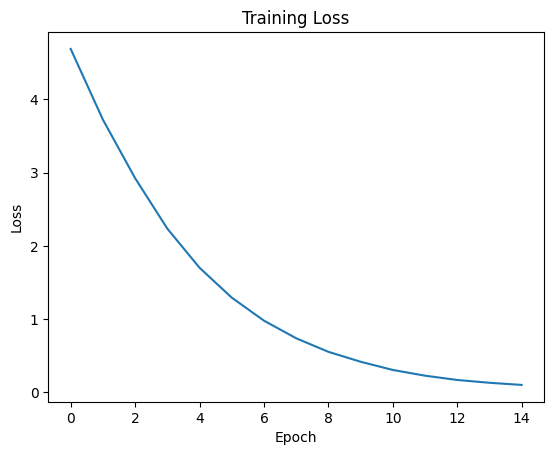

In [9]:
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

### Generation

In [14]:
def generate(seed, words_n=100):

    real_seed = re.findall(r"[a-zA-Z']+", seed.lower())
    real_seed = [w for w in real_seed if w in word_to_id]

    if len(real_seed) == 0:
        real_seed = ["the"]

    result = real_seed[:]

    for _ in range(words_n):
        current_words = result[-seq_len:]
        if len(current_words) < seq_len:
            current_words = ["the"] * (seq_len - len(current_words)) + current_words
        ids = [word_to_id[w] for w in current_words]
        x = torch.tensor([ids], dtype=torch.long)

        with torch.no_grad():
            pred = model(x)
        next_id = torch.argmax(pred, dim=1).item()
        next_word = id_to_word[next_id]

        result.append(next_word)

    return " ".join(result)

In [16]:
generate("it was on a dreary night of november", 25)

'it was on a dreary night of november that you may deduce an apt moral from my tale one that may direct you if you succeed in your undertaking and console you in'